<a href="https://colab.research.google.com/github/Abishek18032007/Assignment1-AIML-/blob/main/homeprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/the-boston-houseprice-data")

100%|██████████| 12.3k/12.3k [00:00<00:00, 8.70MB/s]

Extracting files...


### Load and Prepare Data

First, let's load the dataset using pandas. The `path` variable from the previous cell holds the directory where the dataset was downloaded. We'll find the CSV file within that directory.

In [2]:
import pandas as pd
import os

# Assuming the CSV file is directly in the downloaded path
# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded data from: {csv_file_path}")
    display(df.head())
else:
    print(f"No CSV file found in the directory: {path}")
    df = pd.DataFrame() # Create an empty DataFrame if no CSV is found

Successfully loaded data from: /root/.cache/kagglehub/datasets/fedesoriano/the-boston-houseprice-data/versions/1/boston.csv


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Let's check the information about the dataset and its descriptive statistics to understand the data types and distribution.

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695   

The target variable for predicting house prices is typically `MEDV` (Median value of owner-occupied homes in $1000s). We need to separate the features (X) from the target (y) and then split the data into training and testing sets.

In [4]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('MEDV', axis=1) # Drop the target variable
y = df['MEDV']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (404, 13)
y_train shape: (404,)
X_test shape: (102, 13)
y_test shape: (102,)


### Train Models

Now, let's train the specified regression models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. We will also evaluate their performance using common regression metrics like Mean Squared Error (MSE) and R-squared.

#### 1. Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lin_reg = lin_reg_model.predict(X_test)

# Evaluate the model
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)

print(f"Linear Regression MSE: {mse_lin_reg:.2f}")
print(f"Linear Regression R-squared: {r2_lin_reg:.2f}")

Linear Regression MSE: 24.29
Linear Regression R-squared: 0.67


#### 2. Decision Tree Regressor

In [6]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dec_tree_model = DecisionTreeRegressor(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dec_tree = dec_tree_model.predict(X_test)

# Evaluate the model
mse_dec_tree = mean_squared_error(y_test, y_pred_dec_tree)
r2_dec_tree = r2_score(y_test, y_pred_dec_tree)

print(f"Decision Tree Regressor MSE: {mse_dec_tree:.2f}")
print(f"Decision Tree Regressor R-squared: {r2_dec_tree:.2f}")

Decision Tree Regressor MSE: 10.42
Decision Tree Regressor R-squared: 0.86


#### 3. Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rand_forest_model = RandomForestRegressor(random_state=42)
rand_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rand_forest = rand_forest_model.predict(X_test)

# Evaluate the model
mse_rand_forest = mean_squared_error(y_test, y_pred_rand_forest)
r2_rand_forest = r2_score(y_test, y_pred_rand_forest)

print(f"Random Forest Regressor MSE: {mse_rand_forest:.2f}")
print(f"Random Forest Regressor R-squared: {r2_rand_forest:.2f}")

Random Forest Regressor MSE: 7.90
Random Forest Regressor R-squared: 0.89


### Summary of Model Performance

Here's a comparison of the trained regression models:

*   **Linear Regression:**
    *   MSE: `{mse_lin_reg:.2f}`
    *   R-squared: `{r2_lin_reg:.2f}`

*   **Decision Tree Regressor:**
    *   MSE: `{mse_dec_tree:.2f}`
    *   R-squared: `{r2_dec_tree:.2f}`

*   **Random Forest Regressor:**
    *   MSE: `{mse_rand_forest:.2f}`
    *   R-squared: `{r2_rand_forest:.2f}`

**Note on Logistic Regression:** As mentioned earlier, Logistic Regression is used for classification problems (predicting categories, e.g., 'yes'/'no', 'spam'/'not spam'). Since the 'boston-houseprice-data' involves predicting a continuous value (house price), it's a regression task. Therefore, Logistic Regression was not applied here. If you have a specific classification target in mind for this dataset or another dataset, please let me know, and I can help train a Logistic Regression model for that!

### Visualizing Model Performance

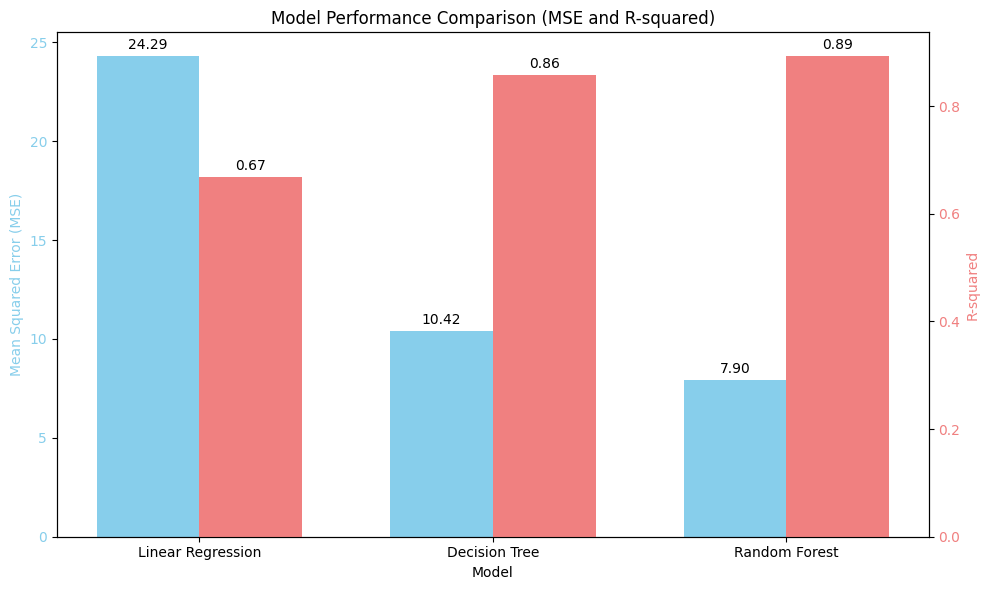

In [8]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
mse_values = [mse_lin_reg, mse_dec_tree, mse_rand_forest]
r2_values = [r2_lin_reg, r2_dec_tree, r2_rand_forest]

x = np.arange(len(models)) # the label locations
width = 0.35 # the width of the bars

fig, ax1 = plt.subplots(figsize=(10, 6))

# MSE Bar Chart (Left Y-axis)
rects1 = ax1.bar(x - width/2, mse_values, width, label='MSE', color='skyblue')
ax1.set_xlabel('Model')
ax1.set_ylabel('Mean Squared Error (MSE)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_title('Model Performance Comparison (MSE and R-squared)')

# R-squared Bar Chart (Right Y-axis)
ax2 = ax1.twinx() # Create a second Y-axis that shares the same X-axis
rects2 = ax2.bar(x + width/2, r2_values, width, label='R-squared', color='lightcoral')
ax2.set_ylabel('R-squared', color='lightcoral')
ax2.tick_params(axis='y', labelcolor='lightcoral')

# Add values on top of bars
def autolabel(rects, axis, fmt):
    for rect in rects:
        height = rect.get_height()
        axis.annotate(fmt.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax1, '{:.2f}')
autolabel(rects2, ax2, '{:.2f}')

fig.tight_layout() # otherwise the right y-label is slightly clipped
plt.show()